In [1]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pydub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
base_path = "C:/Users/maany/Birdie"

In [37]:
from pydub import AudioSegment
import os

mp3_folder = "C:/Users/maany/birdie/bird_data/train"
wav_folder = "C:/Users/maany/birdie/data_wav"
os.makedirs(wav_folder, exist_ok=True)

for file in os.listdir(mp3_folder):
    if file.endswith(".mp3"):
        sound = AudioSegment.from_mp3(os.path.join(mp3_folder, file))
        wav_path = os.path.join(wav_folder, file.replace(".mp3", ".wav"))
        sound.export(wav_path, format="wav")

In [38]:
import librosa
import numpy as np

def extract_mel_spectrogram(file_path):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

In [39]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity_matrix(files):
    specs = [extract_mel_spectrogram(f).flatten() for f in files]
    specs = np.array(specs)
    sim_matrix = cosine_similarity(specs)
    return sim_matrix

In [41]:
print(os.makedirs("bir_test/data_wav/test.wav", exist_ok=True))

None


In [42]:
test_file = r"C:\Users\maany\Birdie\bird_data\test.wav"
train_files = [f for f in os.listdir(wav_folder) if f != "test.wav"]
train_paths = [os.path.join(wav_folder, f) for f in train_files]

In [45]:
pip install audioread

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
file_path = r"C:\Users\maany\Birdie\bird_data\train\bird1.mp3"

In [49]:
import audioread
try:
    with audioread.audio_open(file_path) as f:
        print(f"Duration: {f.duration:.2f} seconds")
        print(f"Channels: {f.channels}")
        print(f"Sample rate: {f.samplerate}")
        
        audio_data = b''.join([buf for buf in f])
        print(f"Read {len(audio_data)} bytes of audio")
except Exception as e:
    print(f"Failed to read audio: {e}")

Duration: 47.10 seconds
Channels: 2
Sample rate: 44100
Read 8313932 bytes of audio


In [50]:
import audioread
import os

folder_path = r"C:\Users\maany\Birdie\bird_data\train"

for file in os.listdir(folder_path):
    if file.endswith(".mp3") or file.endswith(".wav"):
        file_path = os.path.join(folder_path, file)
        try:
            with audioread.audio_open(file_path) as f:
                print(f"File: {file}")
                print(f"Duration: {f.duration:.2f} seconds")
                print(f"Channels: {f.channels}")
                print(f"Sample rate: {f.samplerate}")
        except Exception as e:
            print(f"Failed to read {file}: {e}")

File: bird1.mp3
Duration: 47.10 seconds
Channels: 2
Sample rate: 44100
File: XC665603 - Jungle Babbler - Argya striata sindiana.mp3
Duration: 40.20 seconds
Channels: 2
Sample rate: 44100
File: XC684276 - Jungle Babbler - Argya striata.mp3
Duration: 13.60 seconds
Channels: 2
Sample rate: 44100
File: XC684277 - Jungle Babbler - Argya striata.mp3
Duration: 73.40 seconds
Channels: 2
Sample rate: 44100
File: XC684287 - Jungle Babbler - Argya striata.mp3
Duration: 46.70 seconds
Channels: 2
Sample rate: 44100
File: XC809152 - Jungle Babbler - Argya striata.mp3
Duration: 149.70 seconds
Channels: 2
Sample rate: 44100
File: XC809675 - Jungle Babbler - Argya striata.mp3
Duration: 119.20 seconds
Channels: 2
Sample rate: 44100
File: XC809676 - Jungle Babbler - Argya striata.mp3
Duration: 172.00 seconds
Channels: 2
Sample rate: 44100
File: XC809677 - Jungle Babbler - Argya striata.mp3
Duration: 74.90 seconds
Channels: 2
Sample rate: 44100
File: XC844618 - Jungle Babbler - Argya striata.wav
Duration:

In [ ]:
---------------------------------------------------------------------------------------

In [51]:
from pydub import AudioSegment
import os

mp3_path = r"C:\Users\maany\Birdie\bird_data\train\bird1.mp3"
wav_path = mp3_path.replace(".mp3", ".wav")

sound = AudioSegment.from_file(mp3_path)
sound.export(wav_path, format="wav")

<_io.BufferedRandom name='C:\\Users\\maany\\Birdie\\bird_data\\train\\bird1.wav'>

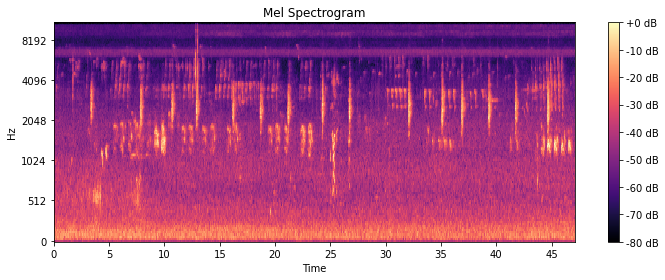

In [52]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load WAV file
y, sr = librosa.load(wav_path)

# Generate Mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)

# Plot and save
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel Spectrogram')
plt.tight_layout()
plt.savefig("spectrogram_bird1.png")
plt.show()

In [69]:
import librosa
import numpy as np

def extract_mel_spectrogram(file_path, n_mels=128):
    y, sr = librosa.load(file_path, sr=None)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db.flatten()  # Flatten for similarity comparison

In [70]:
import os

train_folder = r"C:\Users\maany\Birdie\bird_data\train"
train_features = []
train_files = []

for file in os.listdir(train_folder):
    if file.endswith(".wav"):
        path = os.path.join(train_folder, file)
        features = extract_mel_spectrogram(path)
        train_features.append(features)
        train_files.append(file)

train_features = np.array(train_features)

C:\Users\maany\AppData\Local\Temp\ipykernel_17768\1733398683.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  train_features = np.array(train_features)


In [71]:
import librosa
import numpy as np
import os

def generate_spectrogram(path, sr=22050, n_mels=128):
    y, _ = librosa.load(path, sr=sr)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

In [72]:
def clean_spectrogram(S_db):
    # Normalize to [0, 1]
    S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min())
    # Optional: remove low-energy frames
    S_db[S_db < 0.1] = 0
    return S_db

In [73]:
from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity_matrix(spectrograms):
    # Flatten each spectrogram
    flattened = [spec.flatten() for spec in spectrograms]
    return cosine_similarity(flattened)

In [79]:
import librosa
import numpy as np
import os

def generate_spectrogram(path, sr=22050, n_mels=128):
    y, _ = librosa.load(path, sr=sr)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

# Directory containing WAV files
audio_dir = "C:\Users\maany\Birdie\data_wav"
spectrograms = []

for filename in os.listdir(audio_dir):
    if filename.endswith(".wav"):
        path = os.path.join(audio_dir, filename)
        try:
            spec = generate_spectrogram(path)
            spectrograms.append(spec)
        except Exception as e:
            print(f"Error processing {filename}: {e}")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2183522773.py, line 12)

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = [spec.flatten() for spec in spectrograms]
y = labels  # e.g., ['sparrow', 'crow', ...]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

NameError: name 'spectrograms' is not defined

In [58]:
from sklearn.metrics.pairwise import cosine_similarity

test_file = r"C:\Users\maany\Birdie\bird_data\test.wav"
test_features = extract_mel_spectrogram(test_file).reshape(1, -1)

C:\Users\maany\AppData\Local\Temp\ipykernel_17768\2559361834.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)


PermissionError: [Errno 13] Permission denied: 'C:\\Users\\maany\\Birdie\\bird_data\\test.wav'

In [ ]:
similarities = cosine_similarity(test_features, train_features)[0]
top_indices = np.argsort(similarities)[-5:][::-1]  # Top 5 matches

for i in top_indices:
    print(f"Match: {train_files[i]} | Similarity Score: {similarities[i]:.2f}")

In [36]:
test_spec = extract_mel_spectrogram(test_file).flatten().reshape(1, -1)
train_specs = [extract_mel_spectrogram(f).flatten() for f in train_paths]

scores = cosine_similarity(test_spec, train_specs)[0]
top_indices = np.argsort(scores)[-5:][::-1]

for i in top_indices:
    print(f"Match: {train_files[i]} | Similarity Score: {scores[i]:.2f}")

NameError: name 'test_spec' is not defined